In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import time

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']=120
plt.rcParams['figure.figsize']=(10,6)

np.set_printoptions(precision=4, suppress=True)

In [4]:
class LinearRegression:
    def __init__(self,learning_rate=0.01,
n_iterations=1000,method='normal_eq',verbose=False):
        self.learning_rate=learning_rate
        self.n_iterations=n_iterations
        self.method=method
        self.verbose=verbose
        self.theta=None
        self.cost_history=[]
    def _add_intercept(self,X):
        ones=np.ones((X.shape[0],1))
        return np.hstack((ones,X))
    def _compute_cost(self,X_b,y):
        m=len(y)
        y_pred=X_b@self.theta
        return 1/(2*m)*np.sum((y_pred-y)**2)
    def fit(self,X,y):
        X_b=self._add_intercept(X)
        m,n_features=X_b.shape
        if self.method=='normal_eq':
            self.theta=np.linalg.inv(X_b.T@X_b)@X_b.T@y
        elif self.method=='gd':
            self.theta=np.random.randn(n_features)
            self.cost_history=[]
            for iteration in range(self.n_iterations):
                y_pred=X_b@self.theta
                errors=y_pred-y
                gradient=X_b.T@errors/m
                self.theta-=self.learning_rate*gradient
                cost=self._compute_cost(X_b,y)
                self.cost_history.append(cost)
                if self.verbose and iteration%200==0:
                    print(f"   Iteration {iteration:>5d}: Cost={cost:.6f}")
        return self
    def predict(self,X):
        X_b=self._add_intercept(X)
        return X_b@self.theta
    def score(self,X,y):
        y_pred=self.predict(X)
        ss_res=np.sum((y-y_pred)**2)
        ss_tot=np.sum((y-np.mean(y))**2)
        return 1-ss_res/ss_tot
    def mse(self,X,y):
        y_pred=self.predict(X)
        return np.mean((y-y_pred)**2)



In [5]:
housing=fetch_california_housing()
X=housing.data
y=housing.target
feature_names=housing.feature_names
print(f"数据集大小: {X.shape}")
print(f"特征名称: {feature_names}")
print(f"目标变量: 房产中位数（单位：10万美元）")
print(f"\n目标变量统计:")
print(f"   均值: {np.mean(y):.4f},   标准差: {np.std(y):.4f}")
print(f"   最小值: {np.min(y):.4f},   最大值: {np.max(y):.4f}")

数据集大小: (20640, 8)
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量: 房产中位数（单位：10万美元）

目标变量统计:
   均值: 2.0686,   标准差: 1.1539
   最小值: 0.1500,   最大值: 5.0000


In [6]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)
print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"标准化后特征均值: {X_train.mean(axis=0)[:3]}")
print(f"标准化后特征标准差: {X_train.std(axis=0)[:3]}")


训练集大小: (16512, 8)
测试集大小: (4128, 8)
标准化后特征均值: [ 0.0053 -0.0025  0.0025]
标准化后特征标准差: [1.0023 1.0013 0.9649]


In [7]:
print("="*60)
print("方法一：正规方程")
print("="*60)
start_time=time.time()
model_ne=LinearRegression(method='normal_eq')
model_ne.fit(X_train,y_train)
ne_time=time.time()-start_time
y_pred_train_ne=model_ne.predict(X_train)
y_pred_test_ne=model_ne.predict(X_test)
train_r2_ne=model_ne.score(X_train,y_train)
test_r2_ne=model_ne.score(X_test,y_test)
train_mse_ne=model_ne.mse(X_train,y_train)
test_mse_ne=model_ne.mse(X_test,y_test)
print(f"\n训练时间: {ne_time:.6f} 秒")
print(f"\n【训练集表现】")
print(f"   R^2: {train_r2_ne:.4f},   MSE: {train_mse_ne:.4f}")
print(f"\n【模型权重】")
for name,coef in zip(['Intercept']+list(feature_names),model_ne.theta):
    print(f"   {name:<15}: {coef:>10.4f}")


方法一：正规方程

训练时间: 0.110178 秒

【训练集表现】
   R^2: 0.6126,   MSE: 0.5179

【模型权重】
   Intercept      :     2.0679
   MedInc         :     0.8524
   HouseAge       :     0.1224
   AveRooms       :    -0.3051
   AveBedrms      :     0.3711
   Population     :    -0.0023
   AveOccup       :    -0.0366
   Latitude       :    -0.8966
   Longitude      :    -0.8689


In [8]:
print("=" * 60)
print("方法2：梯度下降（Gradient Descent）")
print("=" * 60)
print("训练中（每200轮打印一次代价）...\n")
start_time = time.time()
model_gd = LinearRegression(
    learning_rate=0.1,        # 标准化后数据可使用较大学习率
    n_iterations=1000,
    method='gd',
    verbose=True
)
model_gd.fit(X_train, y_train)
gd_time = time.time() - start_time
y_pred_train_gd = model_gd.predict(X_train)
y_pred_test_gd = model_gd.predict(X_test)
train_r2_gd = model_gd.score(X_train, y_train)
test_r2_gd = model_gd.score(X_test, y_test)
train_mse_gd = model_gd.mse(X_train, y_train)
test_mse_gd = model_gd.mse(X_test, y_test)
print(f"\n训练时间: {gd_time:.6f} 秒")
print(f"\n【训练集表现】")
print(f"  R²  : {train_r2_gd:.4f}")
print(f"  MSE : {train_mse_gd:.4f}")
print(f"\n【测试集表现】")
print(f"  R²  : {test_r2_gd:.4f}")
print(f"  MSE : {test_mse_gd:.4f}")
print(f"\n【模型权重（标准化后的特征）】")
for name, coef in zip(['Intercept'] + list(feature_names), model_gd.theta):
    print(f"  {name:<15s}: {coef:>10.4f}")

方法2：梯度下降（Gradient Descent）
训练中（每200轮打印一次代价）...

   Iteration     0: Cost=5.152736
   Iteration   200: Cost=0.267408
   Iteration   400: Cost=0.260325
   Iteration   600: Cost=0.259186
   Iteration   800: Cost=0.259002

训练时间: 0.150431 秒

【训练集表现】
  R²  : 0.6125
  MSE : 0.5179

【测试集表现】
  R²  : 0.5754
  MSE : 0.5564

【模型权重（标准化后的特征）】
  Intercept      :     2.0679
  MedInc         :     0.8564
  HouseAge       :     0.1231
  AveRooms       :    -0.3128
  AveBedrms      :     0.3778
  Population     :    -0.0021
  AveOccup       :    -0.0368
  Latitude       :    -0.8881
  Longitude      :    -0.8609


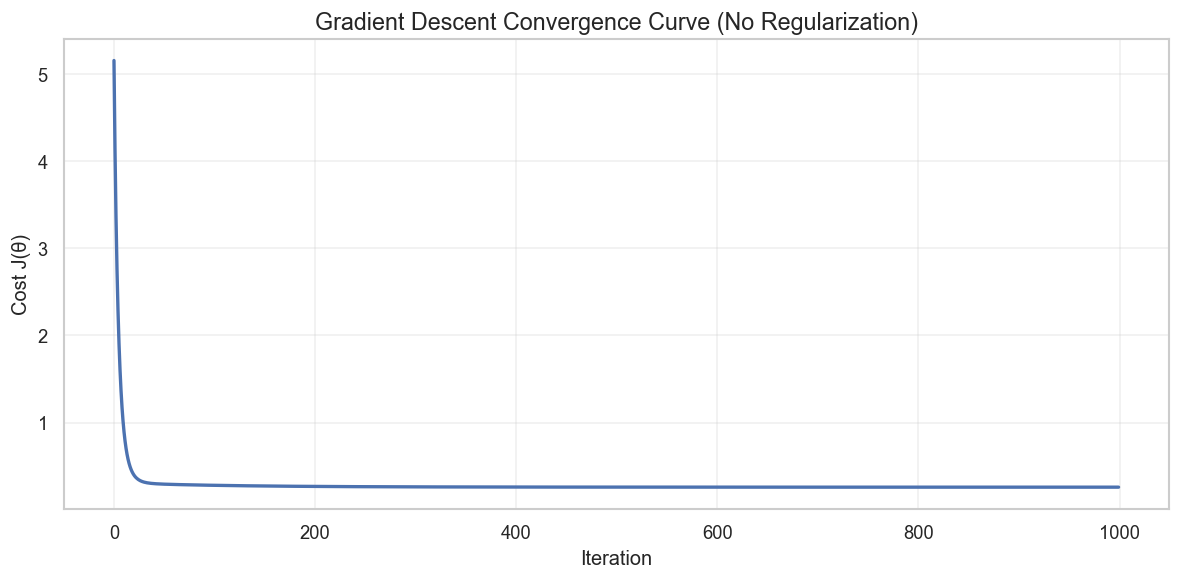

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(model_gd.cost_history, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(θ)', fontsize=12)
plt.title('Gradient Descent Convergence Curve (No Regularization)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    'Method': ['Normal Equation', 'Gradient Descent'],
    'Training Time (s)': [ne_time, gd_time],
    'Train R²': [train_r2_ne, train_r2_gd],
    'Test R²': [test_r2_ne, test_r2_gd],
    'Train MSE': [train_mse_ne, train_mse_gd],
    'Test MSE': [test_mse_ne, test_mse_gd],
})
print(comparison.to_string(index=False))

          Method  Training Time (s)  Train R²  Test R²  Train MSE  Test MSE
 Normal Equation           0.110178  0.612551 0.575788   0.517933  0.555892
Gradient Descent           0.150431  0.612542 0.575401   0.517945  0.556398


C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dll_cyber\AppData\Local\Temp\ipykernel_4220\770924876.py:26: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEO

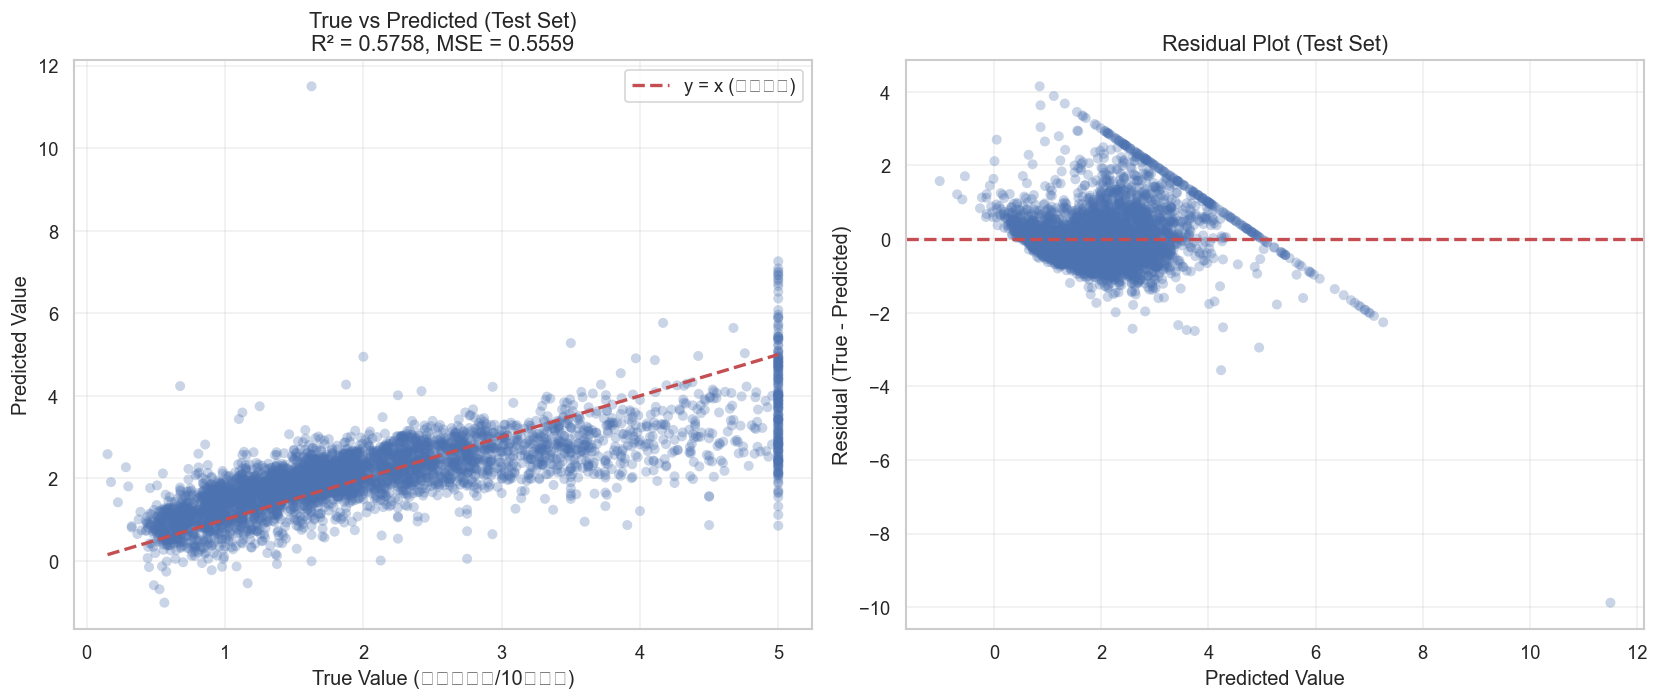

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 子图1：真实值 vs 预测值
ax = axes[0]
y_pred_test = y_pred_test_ne
ax.scatter(y_test, y_pred_test, alpha=0.3, edgecolors='none')
# 画 y=x 参考线
ideal = [min(y_test), max(y_test)]
ax.plot(ideal, ideal, 'r--', linewidth=2, label='y = x (完美预测)')
ax.set_xlabel('True Value (房价中位数/10万美元)', fontsize=12)
ax.set_ylabel('Predicted Value', fontsize=12)
ax.set_title(f'True vs Predicted (Test Set)\nR² = {test_r2_ne:.4f}, MSE = {test_mse_ne:.4f}', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：残差分布
ax = axes[1]
residuals = y_test - y_pred_test
ax.scatter(y_pred_test, residuals, alpha=0.3, edgecolors='none')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Value', fontsize=12)
ax.set_ylabel('Residual (True - Predicted)', fontsize=12)
ax.set_title('Residual Plot (Test Set)', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()